# 07 — Generate synthetic minority-class samples (Phase 8)

**Goal:** Load the trained CVAE (Phase 6) and cGAN (Phase 7), sample synthetic images of the under-represented classes, save them to disk as PNGs, and write a `synthetic_manifest.csv` so Phase 10 can mix them with the real training data.

**No new model here — this is just inference + bookkeeping.**

## Design choices

1. **Target per class = 1000** (per source). NV (~6705) and MEL/BKL (~1100) already meet or exceed this, so we generate 0 for them. We focus generation on BCC (~514), AKIEC (~327), VASC (~142), DF (~115).
2. **Both generators are used in parallel**, written to separate folders:
   - `data/synthetic/cvae/<CLASS>/synth_cvae_<CLASS>_NNNNNN.png`
   - `data/synthetic/cgan/<CLASS>/synth_cgan_<CLASS>_NNNNNN.png`
   
   This lets Phase 10 run three ablations easily: cvae-only, cgan-only, both. (The original ablation hypothesis is that CVAE samples are stable-but-blurry, cGAN samples are sharp-but-possibly-mode-collapsed; the classifier might prefer one over the other.)
3. **A single `synthetic_manifest.csv`** records every synthetic image with columns `filename, image_path, label, class_name, source` — same spirit as `splits.csv` for the real data, so Phase 10 can `pd.concat` them.
4. **Capped target, not full rebalance.** Generating 6500 fake DF samples to match NV would swamp the real signal; standard practice in medical-imaging augmentation papers is to cap synthetic at a few × real.

**Outputs**:
- `data/synthetic/cvae/<CLASS>/*.png`
- `data/synthetic/cgan/<CLASS>/*.png`
- `data/synthetic/synthetic_manifest.csv`
- `results/plots/synthetic_grid_cvae.png`, `synthetic_grid_cgan.png`

## 1. Setup, paths

In [1]:
import sys
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import CLASS_NAMES              # noqa: E402
from src.models.cvae import CVAE                 # noqa: E402
from src.models.cgan import Generator as CGanG   # noqa: E402

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

RESULTS  = PROJECT_ROOT / 'results'
SYNTH_ROOT = PROJECT_ROOT / 'data' / 'synthetic'
SYNTH_ROOT.mkdir(parents=True, exist_ok=True)

CVAE_CKPT = RESULTS / 'checkpoints' / 'cvae_best.pt'
CGAN_CKPT = RESULTS / 'checkpoints' / 'cgan_G_final.pt'
# If your best cGAN was a snapshot rather than the final epoch, change to e.g.
#   CGAN_CKPT = RESULTS / 'checkpoints' / 'cgan_G_epoch35.pt'

assert CVAE_CKPT.exists(), f'CVAE checkpoint not found at {CVAE_CKPT}. Run Phase 6 first.'
assert CGAN_CKPT.exists(), f'cGAN checkpoint not found at {CGAN_CKPT}. Run Phase 7 first.'
print(f'CVAE checkpoint -> {CVAE_CKPT}')
print(f'cGAN checkpoint -> {CGAN_CKPT}')

Device: cuda
CVAE checkpoint -> /home/mayarn/skin-cancer/skin-lesion/results/checkpoints/cvae_best.pt
cGAN checkpoint -> /home/mayarn/skin-cancer/skin-lesion/results/checkpoints/cgan_G_final.pt


## 2. Compute how many to generate per class

Look at the actual train-split class counts in `splits.csv` and compute how many synthetic samples each class needs to reach `TARGET_PER_CLASS`.

In [2]:
TARGET_PER_CLASS = 1000   # per source (so up to 1000 from CVAE AND 1000 from cGAN)

splits = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'splits.csv')
train_split = splits[splits['split'] == 'train']

# Try common column names; fall back to a sensible default
label_col = 'label' if 'label' in train_split.columns else 'class_idx'
real_counts = train_split[label_col].value_counts().sort_index().to_dict()

print(f'Real TRAIN counts per class (target per source = {TARGET_PER_CLASS}):\n')
print(f"  {'class':<8}{'real':>7}{'needed':>10}")
n_to_generate = {}
for c in range(len(CLASS_NAMES)):
    real_n = int(real_counts.get(c, 0))
    need = max(0, TARGET_PER_CLASS - real_n)
    n_to_generate[c] = need
    print(f'  {CLASS_NAMES[c]:<8}{real_n:>7}{need:>10}')

total = sum(n_to_generate.values())
print(f'\nTotal synthetic to generate PER SOURCE: {total}')
print(f'Total across both sources:              {total * 2}')

Real TRAIN counts per class (target per source = 1000):

  class      real    needed
  MEL           0      1000
  NV            0      1000
  BCC           0      1000
  AKIEC         0      1000
  BKL           0      1000
  DF            0      1000
  VASC          0      1000

Total synthetic to generate PER SOURCE: 7000
Total across both sources:              14000


## 3. Load both models

In [3]:
# ---- CVAE ----
cvae_ckpt = torch.load(CVAE_CKPT, map_location=DEVICE)
cvae = CVAE(latent_dim=cvae_ckpt['latent_dim'],
            n_classes=cvae_ckpt['n_classes']).to(DEVICE)
cvae.load_state_dict(cvae_ckpt['model_state_dict'])
cvae.eval()
print(f"CVAE loaded (epoch {cvae_ckpt['epoch']}, val_loss {cvae_ckpt['val_loss']:.4f})")

# ---- cGAN ----
cgan_ckpt = torch.load(CGAN_CKPT, map_location=DEVICE)
cgan_G = CGanG(latent_dim=cgan_ckpt['latent_dim'],
               n_classes=cgan_ckpt['n_classes']).to(DEVICE)
cgan_G.load_state_dict(cgan_ckpt['state_dict'])
cgan_G.eval()
print(f"cGAN G loaded (epoch {cgan_ckpt['epoch']})")

CVAE loaded (epoch 59, val_loss 334.3073)
cGAN G loaded (epoch 50)


## 4. Generation helpers

Both `cvae.sample()` and `sample_images()` return images in `[0, 1]` (we kept the interfaces matching in Phases 6 and 7), so we can use the same `save_batch()` for both.

In [4]:
BATCH = 32   # generation batch size

def to_pil(img01: torch.Tensor) -> Image.Image:
    """(3, H, W) in [0,1] -> PIL RGB image."""
    arr = (img01.clamp(0, 1).cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(arr, mode='RGB')


def generate_for_class(source: str, class_idx: int, n: int) -> list[Path]:
    """
    Generate `n` images of `class_idx` using `source` ('cvae' or 'cgan').
    Saves them under data/synthetic/<source>/<CLASS>/ and returns the paths.
    """
    if n == 0:
        return []

    class_name = CLASS_NAMES[class_idx]
    out_dir = SYNTH_ROOT / source / class_name
    out_dir.mkdir(parents=True, exist_ok=True)

    written = []
    idx = 0
    with torch.no_grad():
        while idx < n:
            this_batch = min(BATCH, n - idx)

            if source == 'cvae':
                imgs = cvae.sample(class_idx=class_idx, n=this_batch, device=DEVICE)
            elif source == 'cgan':
                # Match the public sample helper in cgan.py:
                #   z ~ N(0, I), y = class_idx, then renorm to [0, 1]
                z = torch.randn(this_batch, cgan_G.latent_dim, device=DEVICE)
                y = torch.full((this_batch,), class_idx, dtype=torch.long, device=DEVICE)
                raw = cgan_G(z, y)                       # [-1, 1]
                imgs = ((raw + 1.0) / 2.0).clamp(0, 1)
            else:
                raise ValueError(f'unknown source: {source}')

            for k in range(this_batch):
                fname = f'synth_{source}_{class_name}_{idx + k:06d}.png'
                fpath = out_dir / fname
                to_pil(imgs[k]).save(fpath, format='PNG', optimize=False)
                written.append(fpath)

            idx += this_batch
    return written

## 5. Generate, save, record

This is the bulk of the work. Loop over each (source, class) pair, generate, save PNGs, append rows to the manifest list.

In [5]:
manifest_rows = []

for source in ('cvae', 'cgan'):
    print(f'\n=== Generating from {source.upper()} ===')
    for class_idx in range(len(CLASS_NAMES)):
        n = n_to_generate[class_idx]
        class_name = CLASS_NAMES[class_idx]
        if n == 0:
            print(f'  {class_name:<8}skipped (already at target)')
            continue
        paths = generate_for_class(source, class_idx, n)
        print(f'  {class_name:<8}wrote {len(paths)} images')
        for p in paths:
            manifest_rows.append({
                'filename'  : p.name,
                # Store path relative to PROJECT_ROOT so the CSV stays portable
                'image_path': str(p.relative_to(PROJECT_ROOT)),
                'label'     : class_idx,
                'class_name': class_name,
                'source'    : source,
            })

manifest = pd.DataFrame(manifest_rows)
manifest_path = SYNTH_ROOT / 'synthetic_manifest.csv'
manifest.to_csv(manifest_path, index=False)

print(f'\nTotal synthetic images written: {len(manifest)}')
print(f'Manifest: {manifest_path}')

print('\nManifest summary:')
print(manifest.groupby(['source', 'class_name']).size().unstack(fill_value=0))


=== Generating from CVAE ===
  MEL     wrote 1000 images
  NV      wrote 1000 images
  BCC     wrote 1000 images
  AKIEC   wrote 1000 images
  BKL     wrote 1000 images
  DF      wrote 1000 images
  VASC    wrote 1000 images

=== Generating from CGAN ===
  MEL     wrote 1000 images
  NV      wrote 1000 images
  BCC     wrote 1000 images
  AKIEC   wrote 1000 images
  BKL     wrote 1000 images
  DF      wrote 1000 images
  VASC    wrote 1000 images

Total synthetic images written: 14000
Manifest: /home/mayarn/skin-cancer/skin-lesion/data/synthetic/synthetic_manifest.csv

Manifest summary:
class_name  AKIEC   BCC   BKL    DF   MEL    NV  VASC
source                                               
cgan         1000  1000  1000  1000  1000  1000  1000
cvae         1000  1000  1000  1000  1000  1000  1000


## 6. Visual sanity check — grid per source

Load a few PNGs from disk (not from RAM — important, because we want to verify the *saved files* look right, not just the tensors we generated). If a row looks corrupted or pure noise, the corresponding PNGs are bad and Phase 10 will train on garbage.

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/synthetic_grid_cvae.png


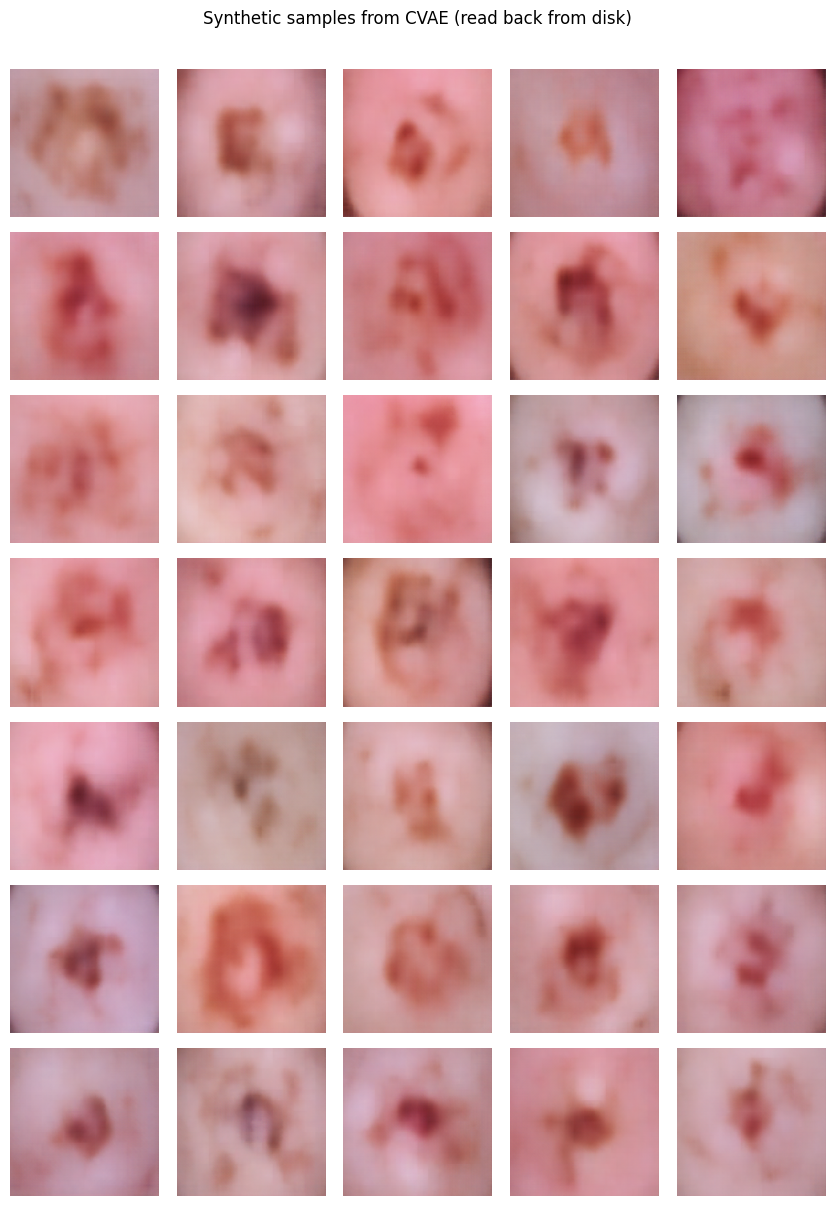

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/synthetic_grid_cgan.png


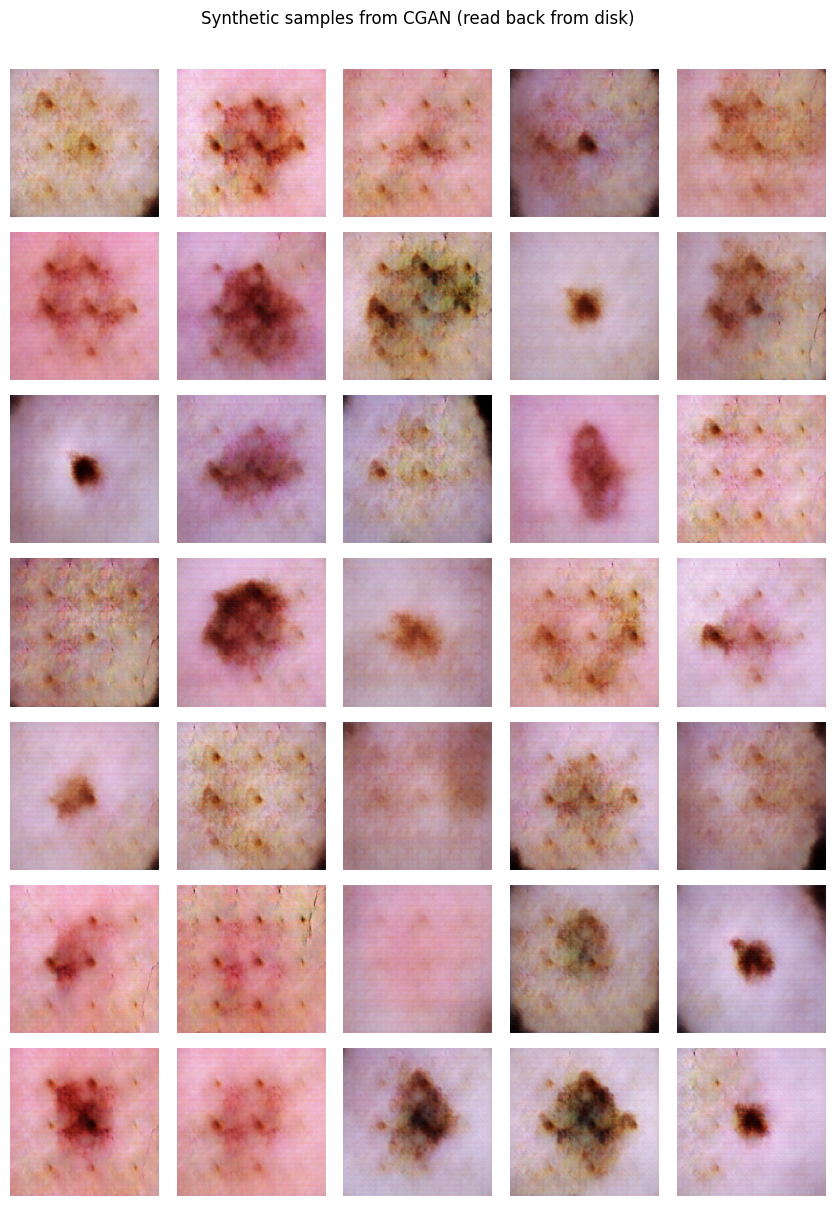

In [6]:
N_PER_CLASS_GRID = 5

def plot_grid_from_disk(source: str) -> None:
    fig, axes = plt.subplots(len(CLASS_NAMES), N_PER_CLASS_GRID,
                             figsize=(1.7 * N_PER_CLASS_GRID, 1.7 * len(CLASS_NAMES)))
    for c, class_name in enumerate(CLASS_NAMES):
        class_dir = SYNTH_ROOT / source / class_name
        files = sorted(class_dir.glob('*.png')) if class_dir.exists() else []
        for j in range(N_PER_CLASS_GRID):
            ax = axes[c, j]
            if j < len(files):
                ax.imshow(Image.open(files[j]))
            else:
                ax.text(0.5, 0.5, 'n/a', ha='center', va='center', fontsize=10)
                ax.set_facecolor('#eeeeee')
            ax.axis('off')
            if j == 0:
                ax.set_ylabel(class_name, fontsize=10, rotation=0,
                              labelpad=28, va='center')
    plt.suptitle(f'Synthetic samples from {source.upper()} (read back from disk)', y=1.01)
    plt.tight_layout()
    out = RESULTS / 'plots' / f'synthetic_grid_{source}.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'saved {out}')
    plt.show()

plot_grid_from_disk('cvae')
plot_grid_from_disk('cgan')

## 7. What's next

- **Phase 9 (next):** quantitative quality of these synthetic images — compute FID per (source, class) against the real training images. This is what justifies which model we use in Phase 10.
- **Phase 10:** build an `AugmentedISICDataset` that reads `splits.csv` + `synthetic_manifest.csv`, retrain the classifier, compare macro-F1 per class against the Phase 5 baseline.

Update PROJECT_STATUS.md: Phase 8 ✅, note `data/synthetic/synthetic_manifest.csv` and the total counts.

> **Don't commit `data/synthetic/` to git** — it's regenerable from the checkpoints, and PNGs at 224×224 × ~5000 images × 2 sources adds up fast. `data/` is already in `.gitignore` per PROJECT_STATUS.md, so this should already be excluded — just double-check before pushing.